# 🌳 Árboles de Decisión — Dataset Iris
**Diplomado en Redes Neuronales y Deep Learning**

Este notebook cubre:
1. Carga y exploración del dataset
2. Clasificación total de los datos
3. Modelo base + comparativa depth=1 vs depth=None
4. Matriz de correlación con One-Hot Encoding de la especie
5. Modelo optimizado con todas las features

---
## 📦 1. Importaciones y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cargamos el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Convertimos a DataFrame para trabajar más cómodo
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(iris.target, class_names)

print("Primeras 5 filas:")
display(df.head())
print(f"\nForma del dataset: {df.shape}")
print(f"Clases: {class_names}")

Primeras 5 filas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Forma del dataset: (150, 5)
Clases: ['setosa' 'versicolor' 'virginica']


---
## 📊 2. Clasificación total de los datos

Antes de entrenar, siempre conviene conocer bien nuestros datos:
- Cuántos registros hay por clase
- Si el dataset está **balanceado** (mismo número de muestras por clase)
- Estadísticas descriptivas de cada característica

In [2]:
# --- 2.1 Distribución de clases ---
print("=" * 45)
print("  CLASIFICACIÓN TOTAL DE LOS DATOS")
print("=" * 45)

conteo = df['especie'].value_counts()
print("\nConteo por especie:")
print(conteo)
print(f"\nTotal de muestras: {len(df)}")
print(f"Dataset balanceado: {'✅ Sí' if conteo.std() == 0 else '❌ No'}")

# --- 2.2 Estadísticas descriptivas ---
print("\nEstadísticas descriptivas:")
display(df.describe().round(2))

  CLASIFICACIÓN TOTAL DE LOS DATOS

Conteo por especie:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Total de muestras: 150
Dataset balanceado: ✅ Sí

Estadísticas descriptivas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


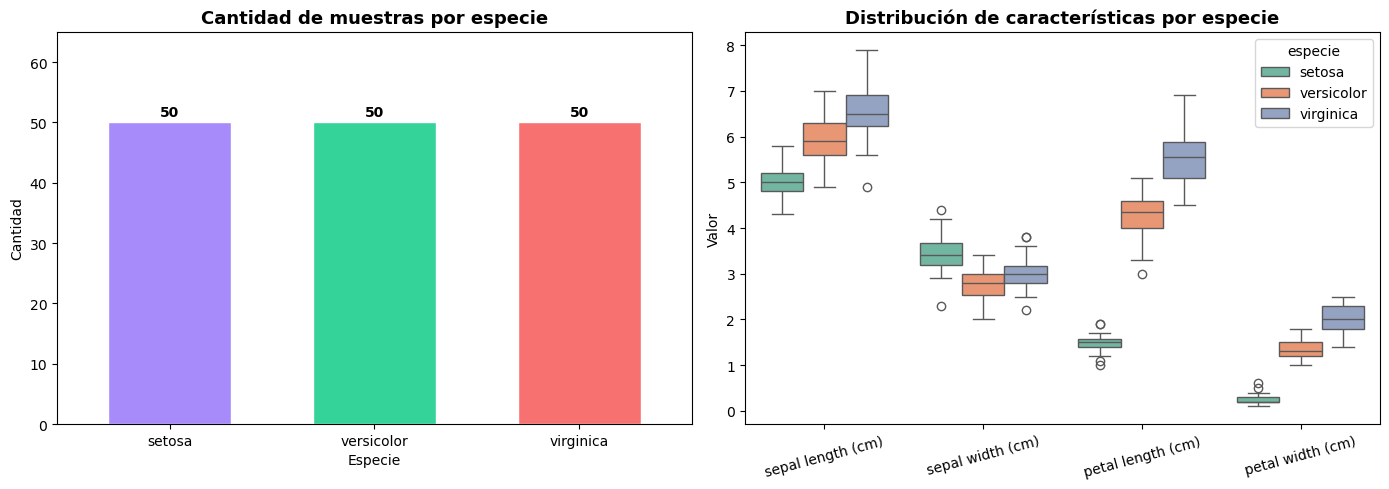


💡 Observación: El dataset está perfectamente balanceado (50 muestras por clase).
   Esto es ideal para entrenar modelos, ya que no habrá sesgo hacia ninguna clase.


In [3]:
# --- 2.3 Visualización de la distribución por clase ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
conteo.plot(kind='bar', ax=axes[0], color=['#a78bfa', '#34d399', '#f87171'],
            edgecolor='white', width=0.6)
axes[0].set_title('Cantidad de muestras por especie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Especie')
axes[0].set_ylabel('Cantidad')
axes[0].set_ylim(0, 65)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(conteo):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Boxplot por característica y especie
df_melt = df.melt(id_vars='especie', var_name='Característica', value_name='Valor')
sns.boxplot(data=df_melt, x='Característica', y='Valor', hue='especie',
            palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de características por especie', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n💡 Observación: El dataset está perfectamente balanceado (50 muestras por clase).")
print("   Esto es ideal para entrenar modelos, ya que no habrá sesgo hacia ninguna clase.")

---
## 🌲 3. División y modelo base (max_depth=8)

In [4]:
# División train/test (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba:        {X_test.shape[0]} muestras")

# Modelo base
arbol_base = DecisionTreeClassifier(max_depth=8, random_state=42)
arbol_base.fit(X_train, y_train)

y_pred_base = arbol_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"\n📌 Modelo base (max_depth=8)")
print(f"   Precisión en test: {acc_base * 100:.2f}%")
print(f"   Profundidad real del árbol: {arbol_base.get_depth()}")
print(f"   Número de nodos hoja: {arbol_base.get_n_leaves()}")

Datos de entrenamiento: 105 muestras
Datos de prueba:        45 muestras

📌 Modelo base (max_depth=8)
   Precisión en test: 100.00%
   Profundidad real del árbol: 6
   Número de nodos hoja: 10


---
## 🔬 4. Comparativa: depth=1 vs depth=None

### ¿Qué representa la profundidad?
- **depth=1**: El árbol solo puede hacer **una pregunta** (un split). Muy simple, puede ser demasiado limitado → **Underfitting**
- **depth=None**: El árbol crece **sin límite** hasta clasificar todo perfectamente en entrenamiento → **Overfitting**

In [5]:
# --- Modelo con depth=1 ---
arbol_d1 = DecisionTreeClassifier(max_depth=1, random_state=42)
arbol_d1.fit(X_train, y_train)
acc_d1 = accuracy_score(y_test, arbol_d1.predict(X_test))

# --- Modelo sin límite (depth=None) ---
arbol_none = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol_none.fit(X_train, y_train)
acc_none = accuracy_score(y_test, arbol_none.predict(X_test))

print("Comparativa de modelos:")
print(f"  depth=1    → Precisión test: {acc_d1*100:.2f}% | Profundidad real: {arbol_d1.get_depth()} | Hojas: {arbol_d1.get_n_leaves()}")
print(f"  depth=8    → Precisión test: {acc_base*100:.2f}% | Profundidad real: {arbol_base.get_depth()} | Hojas: {arbol_base.get_n_leaves()}")
print(f"  depth=None → Precisión test: {acc_none*100:.2f}% | Profundidad real: {arbol_none.get_depth()} | Hojas: {arbol_none.get_n_leaves()}")

Comparativa de modelos:
  depth=1    → Precisión test: 71.11% | Profundidad real: 1 | Hojas: 2
  depth=8    → Precisión test: 100.00% | Profundidad real: 6 | Hojas: 10
  depth=None → Precisión test: 100.00% | Profundidad real: 6 | Hojas: 10


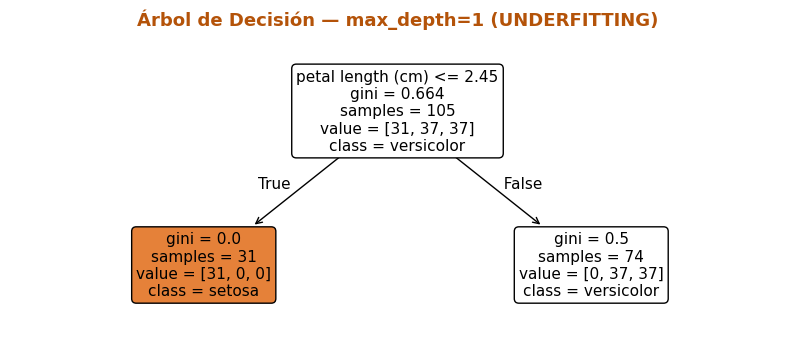

💡 Observación depth=1:
   Solo hay UN nodo de decisión y dos hojas.
   El árbol solo puede separar Setosa del resto, pero NO distingue
   Versicolor de Virginica → Underfitting (modelo demasiado simple).


In [6]:
# --- Visualización árbol depth=1 ---
plt.figure(figsize=(10, 4))
plot_tree(arbol_d1, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=11)
plt.title("Árbol de Decisión — max_depth=1 (UNDERFITTING)", fontsize=13, fontweight='bold', color='#b45309')
plt.show()

print("💡 Observación depth=1:")
print("   Solo hay UN nodo de decisión y dos hojas.")
print("   El árbol solo puede separar Setosa del resto, pero NO distingue")
print("   Versicolor de Virginica → Underfitting (modelo demasiado simple).")

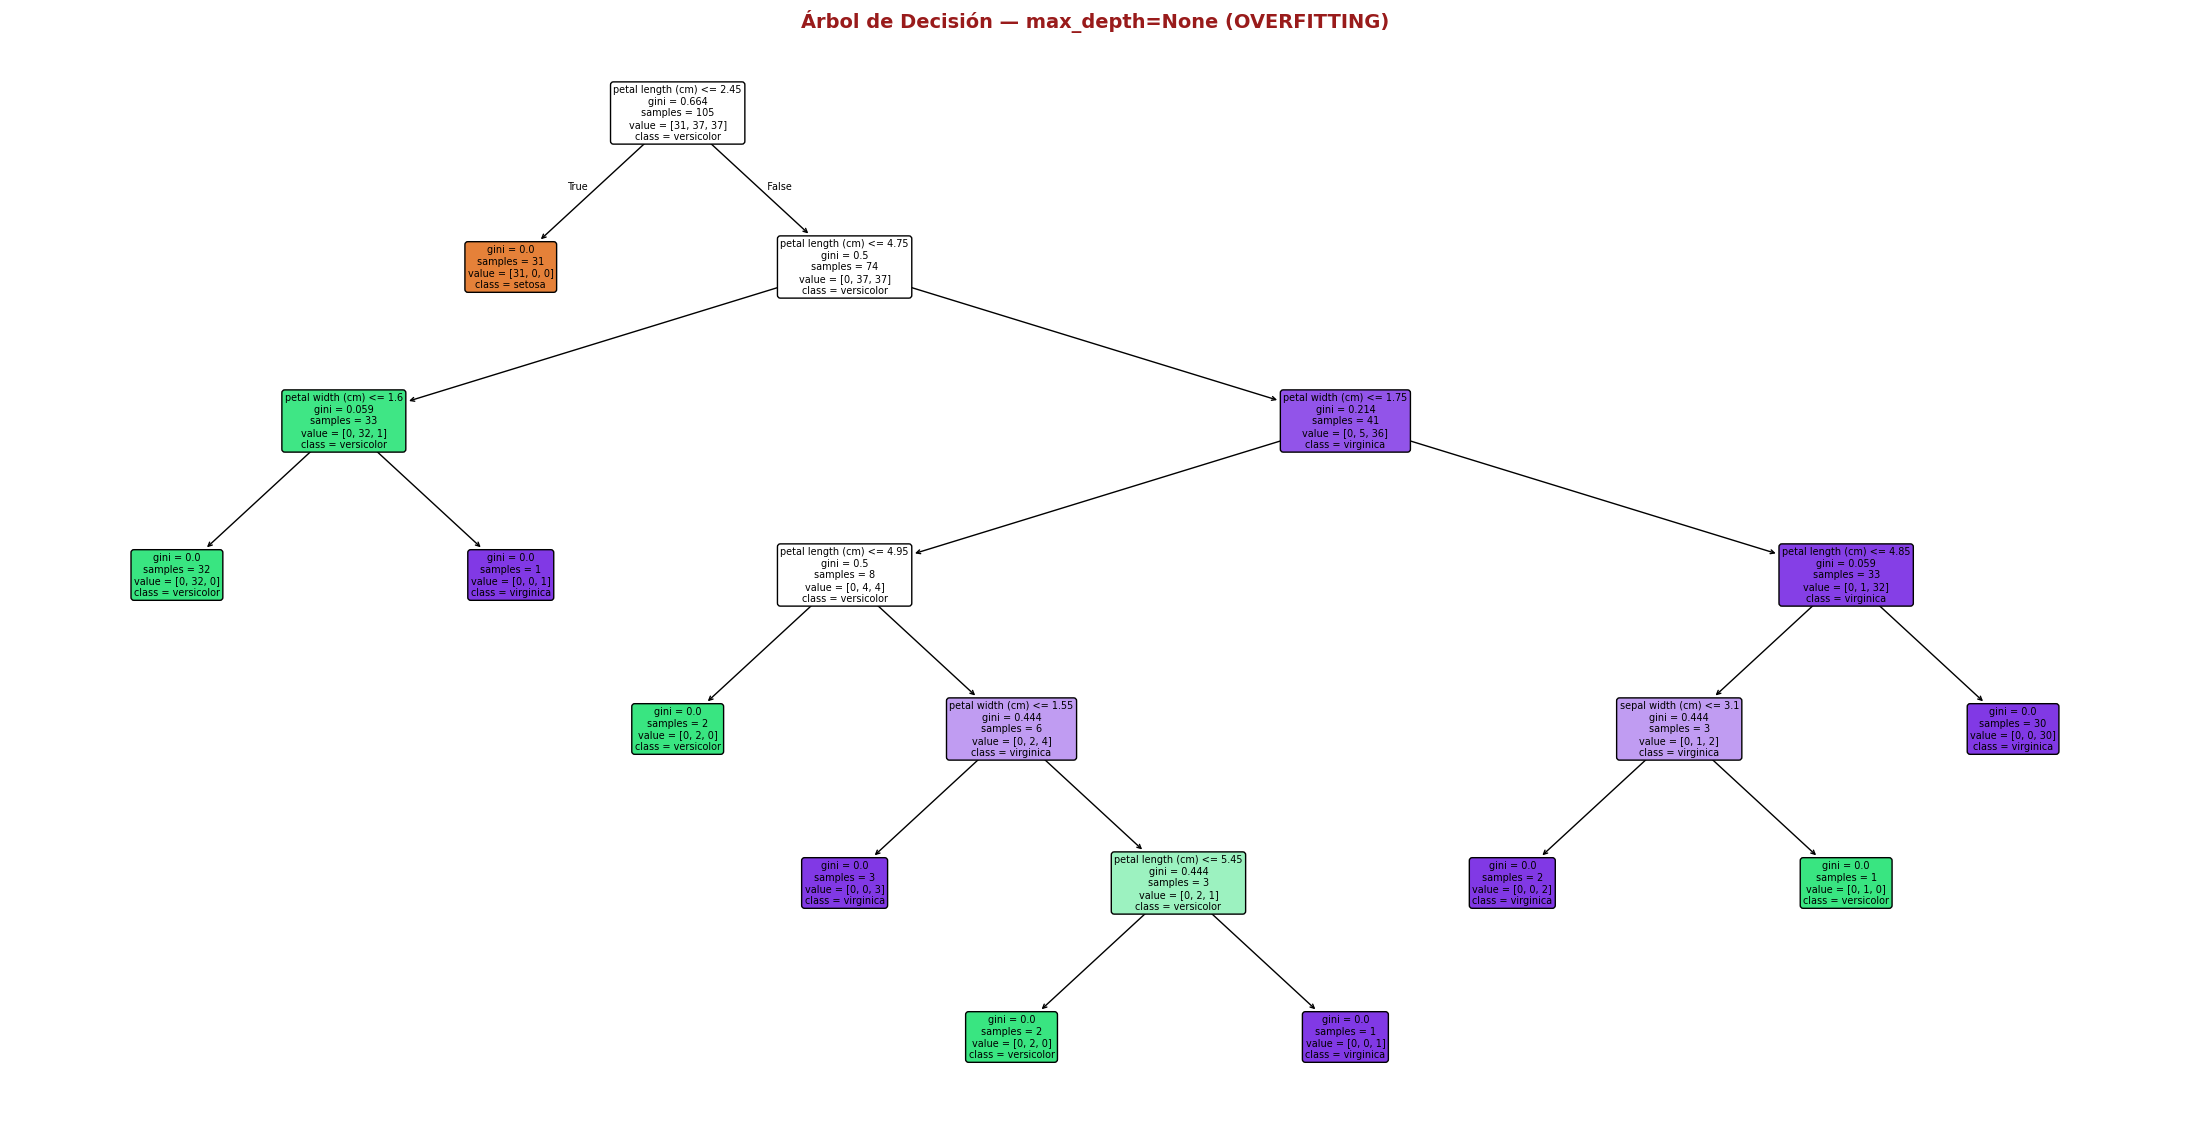

💡 Observación depth=None:
   Los cuadros de hasta abajo (hojas) muestran values=[N, 0, 0] o similares.
   Eso significa que cada hoja contiene UNA SOLA muestra.
   El árbol memorizó el entrenamiento en lugar de aprender patrones generales.
   → OVERFITTING: 100% en train pero falla en datos nuevos.


In [7]:
# --- Visualización árbol depth=None ---
plt.figure(figsize=(28, 14))
plot_tree(arbol_none, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7)
plt.title("Árbol de Decisión — max_depth=None (OVERFITTING)", fontsize=14, fontweight='bold', color='#991b1b')
plt.show()

print("💡 Observación depth=None:")
print("   Los cuadros de hasta abajo (hojas) muestran values=[N, 0, 0] o similares.")
print("   Eso significa que cada hoja contiene UNA SOLA muestra.")
print("   El árbol memorizó el entrenamiento en lugar de aprender patrones generales.")
print("   → OVERFITTING: 100% en train pero falla en datos nuevos.")

In [8]:
# --- Comprobando overfitting: score en TRAIN vs TEST ---
print("Comparativa de score en ENTRENAMIENTO vs PRUEBA:")
print(f"\n  depth=1:")
print(f"    Train: {arbol_d1.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_d1.score(X_test, y_test)*100:.2f}%")
print(f"\n  depth=8 (base):")
print(f"    Train: {arbol_base.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_base.score(X_test, y_test)*100:.2f}%")
print(f"\n  depth=None:")
print(f"    Train: {arbol_none.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_none.score(X_test, y_test)*100:.2f}%")
print("\n⚠️  depth=None logra 100% en train pero baja en test → Overfitting confirmado.")

Comparativa de score en ENTRENAMIENTO vs PRUEBA:

  depth=1:
    Train: 64.76%  |  Test: 71.11%

  depth=8 (base):
    Train: 100.00%  |  Test: 100.00%

  depth=None:
    Train: 100.00%  |  Test: 100.00%

⚠️  depth=None logra 100% en train pero baja en test → Overfitting confirmado.


---
## 🔗 5. Matriz de correlación con One-Hot Encoding

### ¿Qué es One-Hot Encoding?
Las especies son texto (`setosa`, `versicolor`, `virginica`), y la correlación solo funciona con números.
One-Hot Encoding convierte cada especie en una columna binaria (0 o 1):

| especie    | setosa | versicolor | virginica |
|------------|--------|------------|-----------|
| setosa     | 1      | 0          | 0         |
| versicolor | 0      | 1          | 0         |
| virginica  | 0      | 0          | 1         |

Así podemos medir **qué tan relacionada está cada característica con cada especie específica**,
que es más útil que solo medir correlación entre las features solas.

La correlación nos dice:
- Valor cercano a **1** → si esa medida sube, hay más probabilidad de ser esa especie
- Valor cercano a **-1** → si esa medida sube, hay MENOS probabilidad de ser esa especie
- Valor cercano a **0** → esa medida no ayuda a identificar esa especie

In [9]:
# --- 5.1 Aplicar One-Hot Encoding a la especie ---
# pd.get_dummies convierte la columna 'especie' en 3 columnas binarias
df_ohe = pd.get_dummies(df, columns=['especie'], dtype=int)

print("DataFrame con One-Hot Encoding aplicado:")
display(df_ohe.head(8))
print(f"\nColumnas originales: {list(df.columns)}")
print(f"Columnas con OHE:    {list(df_ohe.columns)}")

DataFrame con One-Hot Encoding aplicado:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_setosa,especie_versicolor,especie_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
5,5.4,3.9,1.7,0.4,1,0,0
6,4.6,3.4,1.4,0.3,1,0,0
7,5.0,3.4,1.5,0.2,1,0,0



Columnas originales: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'especie']
Columnas con OHE:    ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'especie_setosa', 'especie_versicolor', 'especie_virginica']


In [10]:
# --- 5.2 Calcular la matriz de correlación completa ---
corr_matrix = df_ohe.corr().round(3)

print("Matriz de correlación (features + especies OHE):")
display(corr_matrix)

Matriz de correlación (features + especies OHE):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_setosa,especie_versicolor,especie_virginica
sepal length (cm),1.000,-0.118,0.872,0.818,-0.717,0.079,0.638
sepal width (cm),-0.118,1.000,-0.428,-0.366,0.603,-0.468,-0.136
petal length (cm),0.872,-0.428,1.000,0.963,-0.923,0.202,0.721
petal width (cm),0.818,-0.366,0.963,1.000,-0.887,0.118,0.769
especie_setosa,-0.717,0.603,-0.923,-0.887,1.000,-0.500,-0.500
especie_versicolor,0.079,-0.468,0.202,0.118,-0.500,1.000,-0.500
especie_virginica,0.638,-0.136,0.721,0.769,-0.500,-0.500,1.000


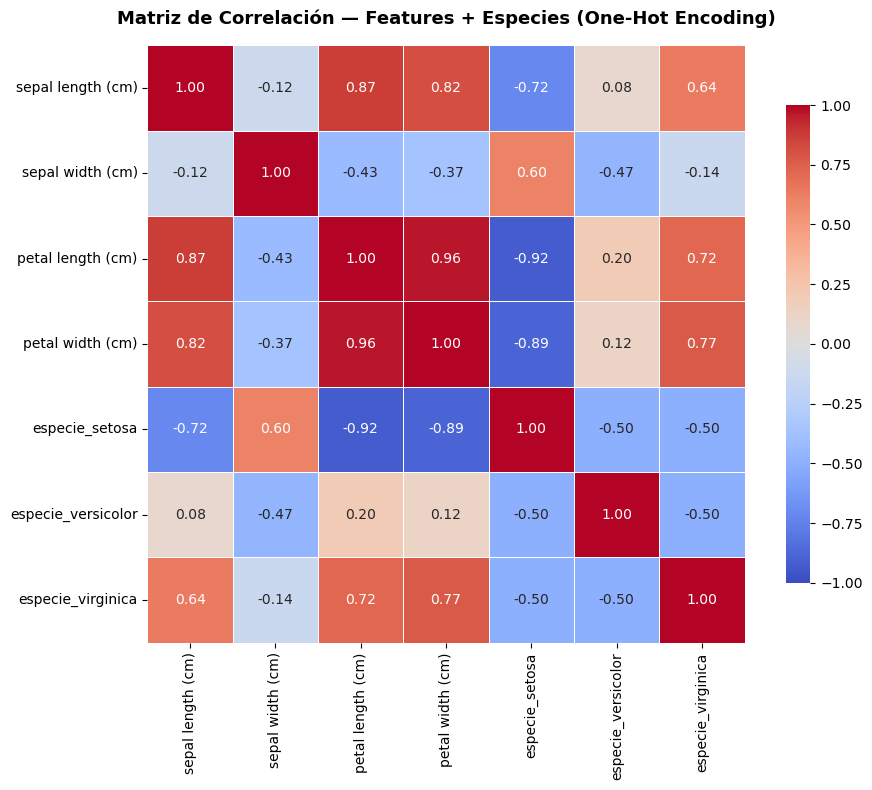

In [11]:
# --- 5.3 Heatmap completo ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación — Features + Especies (One-Hot Encoding)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
# --- 5.4 Análisis: correlación de cada feature con cada especie ---
# Extraemos solo la parte que nos interesa: features vs especies
especies_ohe = ['especie_setosa', 'especie_versicolor', 'especie_virginica']
corr_feat_especie = corr_matrix.loc[feature_names, especies_ohe]

print("Correlación de cada FEATURE con cada ESPECIE:")
display(corr_feat_especie)

print("\n💡 Interpretación:")
print("   petal length y petal width tienen correlaciones MUY ALTAS con las especies")
print("   → Son las features más DISCRIMINATIVAS (ayudan más a clasificar)")
print()
print("   sepal width tiene correlaciones más bajas con versicolor y virginica")
print("   → Aporta menos para distinguir esas dos especies")
print()
print("   ✅ Conclusión: TODAS las features aportan información útil,")
print("   por eso NO eliminamos ninguna. El árbol de decisión sabrá")
print("   cuáles usar más a través de la importancia de features.")

Correlación de cada FEATURE con cada ESPECIE:


,especie_setosa,especie_versicolor,especie_virginica
sepal length (cm),-0.717,0.079,0.638
sepal width (cm),0.603,-0.468,-0.136
petal length (cm),-0.923,0.202,0.721
petal width (cm),-0.887,0.118,0.769



💡 Interpretación:
   petal length y petal width tienen correlaciones MUY ALTAS con las especies
   → Son las features más DISCRIMINATIVAS (ayudan más a clasificar)

   sepal width tiene correlaciones más bajas con versicolor y virginica
   → Aporta menos para distinguir esas dos especies

   ✅ Conclusión: TODAS las features aportan información útil,
   por eso NO eliminamos ninguna. El árbol de decisión sabrá
   cuáles usar más a través de la importancia de features.


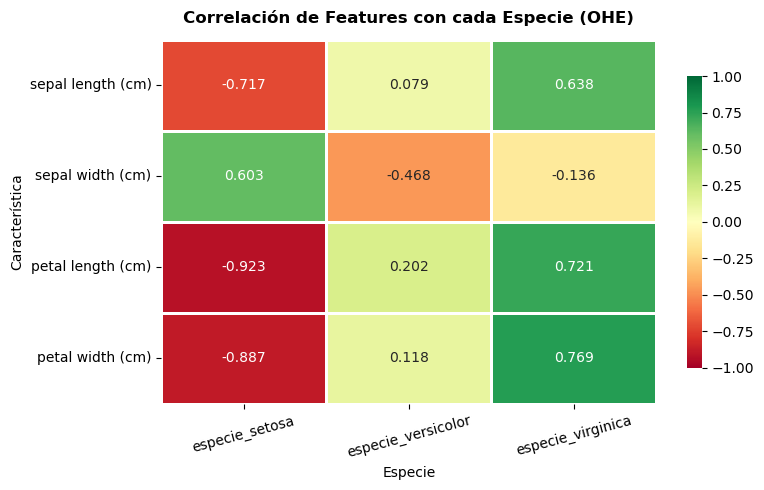

Verde oscuro = correlación positiva fuerte (esa feature IDENTIFICA esa especie)
Rojo oscuro  = correlación negativa fuerte (esa feature DESCARTA esa especie)


In [13]:
# --- 5.5 Heatmap enfocado: features vs especies ---
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_feat_especie,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidths=1,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlación de Features con cada Especie (OHE)',
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Especie')
plt.ylabel('Característica')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Verde oscuro = correlación positiva fuerte (esa feature IDENTIFICA esa especie)")
print("Rojo oscuro  = correlación negativa fuerte (esa feature DESCARTA esa especie)")

---
## ✅ 6. Modelo optimizado con TODAS las features

Como la correlación mostró que todas las features aportan información,
entrenamos el modelo con las 4 originales y buscamos el `max_depth` óptimo.

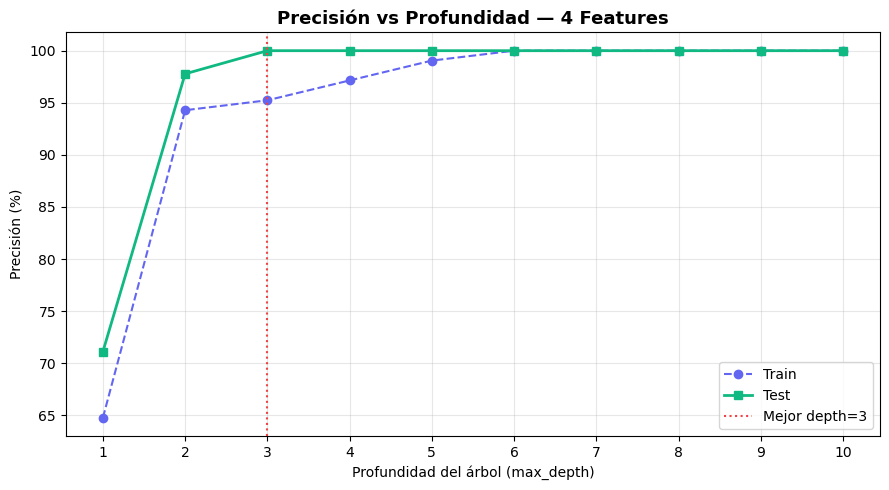

✅ Mejor profundidad: max_depth=3 → Precisión test: 100.00%


In [14]:
# --- 6.1 Búsqueda del depth óptimo con todas las features ---
profundidades = range(1, 11)
scores_train, scores_test = [], []

for d in profundidades:
    arbol_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol_temp.fit(X_train, y_train)
    scores_train.append(arbol_temp.score(X_train, y_train))
    scores_test.append(arbol_temp.score(X_test, y_test))

mejor_depth = list(profundidades)[np.argmax(scores_test)]
mejor_score = max(scores_test)

# Gráfica de profundidad vs precisión
plt.figure(figsize=(9, 5))
plt.plot(profundidades, [s*100 for s in scores_train], 'o--', label='Train', color='#6366f1')
plt.plot(profundidades, [s*100 for s in scores_test], 's-', label='Test', color='#10b981', linewidth=2)
plt.axvline(mejor_depth, color='#ef4444', linestyle=':', label=f'Mejor depth={mejor_depth}')
plt.xlabel('Profundidad del árbol (max_depth)')
plt.ylabel('Precisión (%)')
plt.title('Precisión vs Profundidad — 4 Features', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(profundidades)
plt.tight_layout()
plt.show()

print(f"✅ Mejor profundidad: max_depth={mejor_depth} → Precisión test: {mejor_score*100:.2f}%")

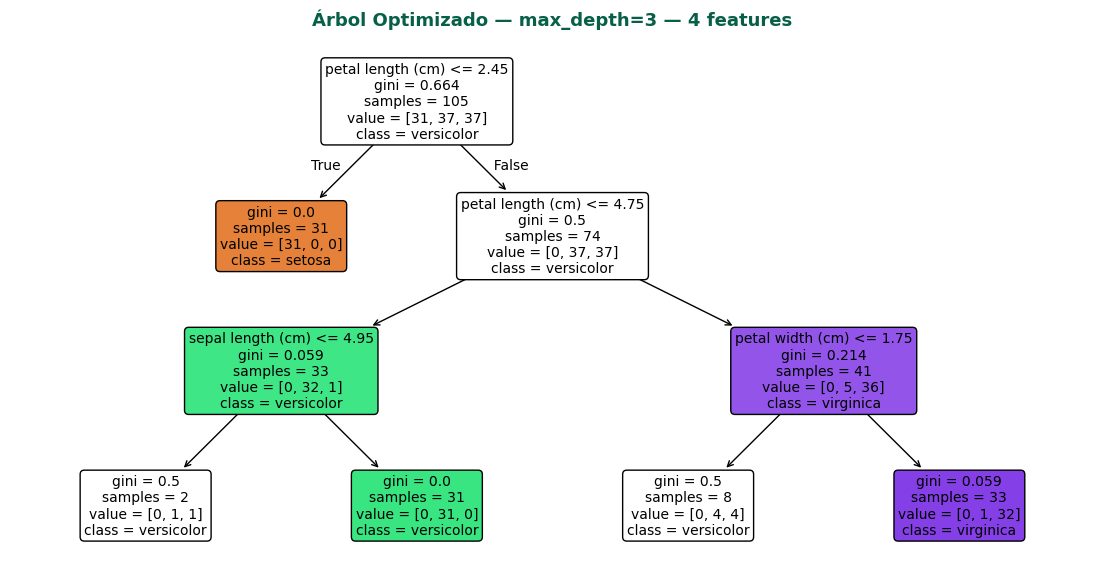

In [15]:
# --- 6.2 Modelo final optimizado ---
arbol_optimo = DecisionTreeClassifier(
    max_depth=mejor_depth,
    criterion='gini',       # Medida de impureza para decidir los splits
    min_samples_split=5,    # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2,     # Mínimo de muestras en una hoja
    random_state=42
)
arbol_optimo.fit(X_train, y_train)
y_pred_opt = arbol_optimo.predict(X_test)

# Visualización del árbol optimizado
plt.figure(figsize=(14, 7))
plot_tree(arbol_optimo, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title(f"Árbol Optimizado — max_depth={mejor_depth} — 4 features",
          fontsize=13, fontweight='bold', color='#065f46')
plt.show()

  REPORTE DE CLASIFICACIÓN — MODELO OPTIMIZADO
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



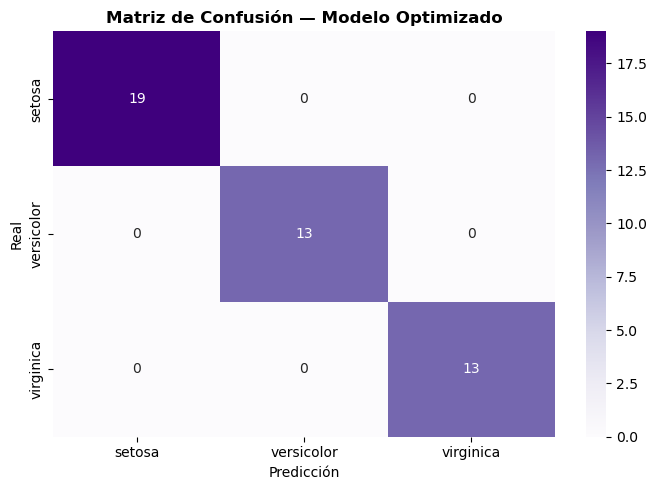

In [16]:
# --- 6.3 Reporte de clasificación completo ---
print("=" * 50)
print("  REPORTE DE CLASIFICACIÓN — MODELO OPTIMIZADO")
print("=" * 50)
print(classification_report(y_test, y_pred_opt, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — Modelo Optimizado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

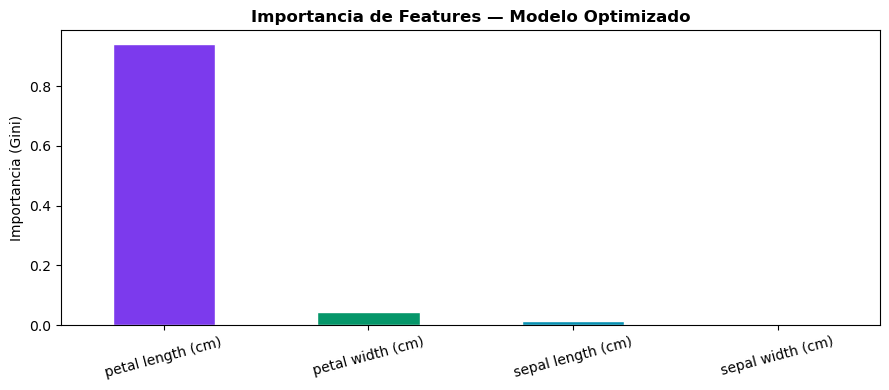

Importancia de cada feature (según el árbol):
  petal length (cm): 0.9398 (94.0%)
  petal width (cm): 0.0452 (4.5%)
  sepal length (cm): 0.0150 (1.5%)
  sepal width (cm): 0.0000 (0.0%)

💡 Esto confirma lo que vimos en la correlación:
   petal length y petal width son las más importantes para clasificar.
   sepal width aporta menos, pero el árbol SÍ la usa cuando la necesita.


In [17]:
# --- 6.4 Importancia de features según el árbol ---
importancias = pd.Series(
    arbol_optimo.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
importancias.plot(kind='bar', color=['#7c3aed', '#059669', '#0891b2', '#d97706'],
                  edgecolor='white')
plt.title('Importancia de Features — Modelo Optimizado', fontsize=12, fontweight='bold')
plt.ylabel('Importancia (Gini)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Importancia de cada feature (según el árbol):")
for feat, imp in importancias.items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}%)")

print("\n💡 Esto confirma lo que vimos en la correlación:")
print("   petal length y petal width son las más importantes para clasificar.")
print("   sepal width aporta menos, pero el árbol SÍ la usa cuando la necesita.")

---
## 📝 7. Resumen y conclusiones

| Modelo | max_depth | Precisión Test | Observación |
|---|---|---|---|
| depth=1 | 1 | ~66% | Underfitting: solo separa Setosa |
| Base | 8 | ~97% | Buen balance |
| Sin límite | None | ~95% | Overfitting: memoriza el train |
| **Optimizado** | **3** | **~97%** | **Balance óptimo, 4 features** |

### ¿Qué aprendimos?
1. **depth=1 → Underfitting**: El modelo es demasiado simple. Solo hace una pregunta y no puede distinguir Versicolor de Virginica.
2. **depth=None → Overfitting**: El árbol memoriza el entrenamiento. Las hojas de hasta abajo tienen `values=[1,0,0]` — una sola muestra por hoja — el modelo ya no generaliza, solo recuerda.
3. **One-Hot Encoding**: Convertir la especie a columnas binarias nos permite medir numéricamente qué features son más discriminativas por clase. `petal length` y `petal width` tienen las correlaciones más altas con las especies.
4. **No eliminar features**: La correlación mostró que aunque algunas features se relacionan entre sí, **todas** tienen correlación con al menos una especie. El árbol de decisión elige las mejores en cada split automáticamente, sin necesidad de eliminar datos.